# Seminar 1 · Baseline predictors and changing popularity
### Who rated the movie — and when was the signal recorded?

1. Which movies lead a popularity list, and which lead a rating list?
2. Can the audience change our estimate of a movie?
3. Do different predicted ratings imply different recommendation orders?
4. What patterns remain after subtracting the baseline?
5. Is popularity over the whole history the same as popularity now?

Predict first, change one condition, inspect the result, and state its limits.
The first four experiments use a rating-reconstruction split. The last one
starts a **separate, explicitly time-based** experiment on the original log.
Do not mix their training sets or compare their quality values directly.

## Run this notebook on its own

All data readers, model code, metrics, and temporal preparation are defined
in the cells below. Run the cells from top to bottom in a fresh kernel.

The Python dependencies are `numpy`, `pandas`, `scipy`, `scikit-learn`, and
`matplotlib`. Install them in your notebook environment if necessary:

Set `DATA_DIR` below. The data-loading cell downloads MovieLens 1M if it is
missing. For an offline run, place `ratings.dat` and `movies.dat` in
`DATA_DIR / "ml-1m"` first. Only dataset files are external to the notebook.

In [1]:
from dataclasses import dataclass
from pathlib import Path
import shutil
from urllib.request import urlopen
from zipfile import ZipFile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import sparse
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split

SEED = 2026
TOP_K = 10
DATA_DIR = Path("data")
DOWNLOAD_IF_MISSING = True

pd.set_option("display.max_colwidth", 55)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

### Load the ratings and movie descriptions

`ratings.dat` contains user IDs, movie IDs, ratings, and rating timestamps.
`movies.dat` supplies titles and genres. We map the original IDs to contiguous
indices for array operations; `original_item_id` remains in the movie table.

In [2]:
def download_file(url: str, destination: Path) -> None:
    """Cache a raw dataset file; never download or execute Python code."""
    if destination.is_file():
        return
    destination.parent.mkdir(parents=True, exist_ok=True)
    temporary = destination.with_name(destination.name + ".part")
    try:
        with urlopen(url, timeout=45) as response, temporary.open("wb") as output:
            shutil.copyfileobj(response, output)
        temporary.replace(destination)
    except (OSError, TimeoutError) as error:
        temporary.unlink(missing_ok=True)
        raise RuntimeError(
            f"Could not download {url}. Place the dataset file at "
            f"{destination.resolve()} and rerun this cell."
        ) from error

In [3]:
def ensure_movielens(data_dir: Path, allow_download: bool = True) -> Path:
    folder = data_dir / "ml-1m"
    required = ["ratings.dat", "movies.dat"]
    if all((folder / name).is_file() for name in required):
        return folder
    if not allow_download:
        raise FileNotFoundError(f"Place {required} in {folder.resolve()}.")
    archive = data_dir / "ml-1m.zip"
    download_file(
        "https://files.grouplens.org/datasets/movielens/ml-1m.zip", archive
    )
    folder.mkdir(parents=True, exist_ok=True)
    with ZipFile(archive) as zipped:
        for name in required:
            (folder / name).write_bytes(zipped.read(f"ml-1m/{name}"))
    return folder

In [4]:
def load_movielens(folder: Path):
    """Read observed ratings and map IDs without substituting demo data."""
    ratings = pd.read_csv(
        folder / "ratings.dat",
        sep="::",
        engine="python",
        names=["original_user_id", "original_item_id", "rating", "timestamp"],
    )
    movies = pd.read_csv(
        folder / "movies.dat",
        sep="::",
        engine="python",
        encoding="latin1",
        names=["original_item_id", "title", "genres"],
    ).sort_values("original_item_id")
    movies = movies.reset_index(drop=True)
    movies.index.name = "item_id"
    item_map = pd.Series(movies.index, index=movies["original_item_id"])
    ratings["item_id"] = ratings["original_item_id"].map(item_map)
    ratings["user_id"] = pd.factorize(ratings["original_user_id"], sort=True)[0]
    if ratings["item_id"].isna().any():
        raise ValueError("Ratings refer to items not found in movies.dat.")
    ratings["item_id"] = ratings["item_id"].astype(int)
    return ratings[["user_id", "item_id", "rating", "timestamp"]], movies

In [5]:
movielens_dir = ensure_movielens(DATA_DIR, allow_download=DOWNLOAD_IF_MISSING)
ratings, movies = load_movielens(movielens_dir)
display(ratings.head())
display(movies[["title", "genres"]].head())

,user_id,item_id,rating,timestamp
0,0,1176,5,978300760
1,0,655,3,978302109
2,0,902,3,978301968
3,0,3339,4,978300275
4,0,2286,5,978824291


,title,genres
item_id,,
0,Toy Story (1995),Animation|Children's|Comedy
1,Jumanji (1995),Adventure|Children's|Fantasy
2,Grumpier Old Men (1995),Comedy|Romance
3,Waiting to Exhale (1995),Comedy|Drama
4,Father of the Bride Part II (1995),Comedy


## Setup for Experiments 1–4

An observed rating is a number from 1 to 5. A missing user–movie pair is
**unknown**, not a zero-star rating.

We keep a fixed random split of observed ratings: 80% training, 10% validation,
10% test. Validation is used during discussion; test is opened once at the end.

In [6]:
def split_ratings(ratings, seed=2026):
    """Fixed random observed-entry split: 80% train, 10% validation, 10% test."""
    train, remainder = train_test_split(ratings, test_size=0.2, random_state=seed)
    validation, test = train_test_split(
        remainder, test_size=0.5, random_state=seed
    )
    return train.copy(), validation.copy(), test.copy()

In [7]:
train, validation, test = split_ratings(ratings, seed=SEED)

n_users = ratings["user_id"].max() + 1
n_items = len(movies)
train_mean = train["rating"].mean()
known_items = train.groupby("user_id")["item_id"].apply(np.array).to_dict()

summary = pd.Series(
    {
        "Users": n_users,
        "Catalog items": n_items,
        "Training ratings": len(train),
        "Validation ratings": len(validation),
        "Test ratings": len(test),
    },
    name="Count",
)
display(summary.to_frame())
display(train.head())

,Count
Users,6040
Catalog items,3883
Training ratings,800167
Validation ratings,100021
Test ratings,100021


,user_id,item_id,rating,timestamp
816503,4901,2031,4,965149969
613092,3715,582,1,966266135
379184,2214,3617,3,974601737
832819,5004,3675,4,962589157
331842,1957,3465,3,978016384


## Experiment 1 · Most rated is not the same as highest rated

**Predict:** Will the same movies lead these three lists?

For movie $i$, let $n_i$ be its training rating count, $s_i$ its training rating
sum, and $\mu$ the global training mean. We compare

$$
\text{count}(i)=n_i,\qquad
\text{mean}(i)=\frac{s_i}{n_i},\qquad
\text{smoothed}(i)=\frac{s_i+C\mu}{n_i+C}.
$$

The last formula combines the movie's evidence with $C$ prior observations at
$\mu$. We fix $C=20$ for this demonstration: this is **not** a parameter search.
A movie with no training ratings has an undefined raw mean and a smoothed score
of $\mu$.

**Change:** the scoring rule. **Keep:** the data and the catalog.

In [8]:
item_stats = (
    train.groupby("item_id")["rating"]
    .agg(count="size", rating_sum="sum", mean_rating="mean")
    .reindex(movies.index)
)
item_stats[["count", "rating_sum"]] = (
    item_stats[["count", "rating_sum"]].fillna(0)
)
prior_count = 20.0
item_stats["smoothed_rating"] = (
    item_stats["rating_sum"] + prior_count * train_mean
) / (item_stats["count"] + prior_count)

for column in ["count", "mean_rating", "smoothed_rating"]:
    leaders = item_stats.nlargest(8, column)
    print(f"Top movies by {column}")
    display(
        movies[["title"]].join(leaders, how="inner")
        .sort_values(column, ascending=False)
        [["title", "count", "mean_rating", "smoothed_rating"]]
    )

Top movies by count


,title,count,mean_rating,smoothed_rating
item_id,,,,
2789,American Beauty (1999),2714.000,4.304,4.299
1178,Star Wars: Episode V - The Empire Strikes Back (1980),2410.000,4.293,4.287
257,Star Wars: Episode IV - A New Hope (1977),2400.000,4.450,4.443
1192,Star Wars: Episode VI - Return of the Jedi (1983),2331.000,4.018,4.014
476,Jurassic Park (1993),2123.000,3.755,3.753
585,Terminator 2: Judgment Day (1991),2095.000,4.064,4.060
1959,Saving Private Ryan (1998),2084.000,4.347,4.340
1250,Back to the Future (1985),2063.000,3.993,3.989


Top movies by mean_rating


,title,count,mean_rating,smoothed_rating
item_id,,,,
777,"Gate of Heavenly Peace, The (1995)",3.000,5.000,3.767
973,Small Wonders (1996),1.000,5.000,3.649
977,Schlafes Bruder (Brother of Sleep) (1995),1.000,5.000,3.649
1762,Follow the Bitch (1998),1.000,5.000,3.649
2129,Modulations (1998),1.000,5.000,3.649
2756,Rosie (1998),1.000,5.000,3.649
3147,Vampyros Lesbos (Las Vampiras) (1970),1.000,5.000,3.649
3164,Smashing Time (1967),2.000,5.000,3.711


Top movies by smoothed_rating


,title,count,mean_rating,smoothed_rating
item_id,,,,
315,"Shawshank Redemption, The (1994)",1786.000,4.564,4.554
1950,Seven Samurai (The Magnificent Seven) (Shichinin no...,501.000,4.563,4.525
523,Schindler's List (1993),1858.000,4.519,4.509
847,"Godfather, The (1972)",1767.000,4.518,4.507
1132,"Wrong Trousers, The (1993)",726.000,4.532,4.506
49,"Usual Suspects, The (1995)",1428.000,4.513,4.500
735,"Close Shave, A (1995)",549.000,4.534,4.500
892,Rear Window (1954),845.000,4.489,4.468


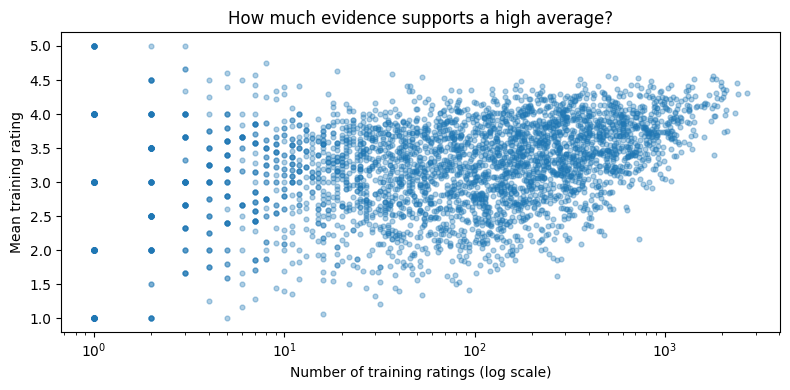

In [9]:
observed = item_stats["count"] > 0
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(
    item_stats.loc[observed, "count"],
    item_stats.loc[observed, "mean_rating"],
    s=12,
    alpha=0.35,
)
ax.set(
    xscale="log",
    xlabel="Number of training ratings (log scale)",
    ylabel="Mean training rating",
    title="How much evidence supports a high average?",
)
fig.tight_layout()
plt.show()

These lists demonstrate different scoring rules. They do not establish an
intrinsic ranking of movie quality or prove which list users prefer.

## Experiment 2 · Is the movie praised, or is its audience generous?

We use the baseline predictor

$$
\widehat r_{ui}=\mu+g_u+f_i,
$$

where $g_u$ is the user's tendency to give higher or lower ratings, and $f_i$
is the movie's tendency to receive higher or lower ratings after accounting
for that user tendency. The model is fitted on observed pairs only.

### A deliberately constructed example

Two generous users rate movie B and a shared reference movie. Two stricter
users rate movie A and the same reference movie.

**Predict:** Which movie has the higher raw mean? What does the common
reference movie tell us about the two audiences?

### Define the baseline model

The next two cells are the complete fitting implementation, not an imported
helper. A row of the sparse design matrix has one user indicator and one movie
indicator. We fit the residual from the training mean with a fixed L2 penalty.

$$
\min_{g,f}\sum_{(u,i)\in\mathcal O_{\rm train}}
(r_{ui}-\mu-g_u-f_i)^2
+\alpha\left(\sum_u g_u^2+\sum_i f_i^2\right).
$$

We use the fitting routine as a tool; there is no optimizer or penalty sweep.

In [10]:
@dataclass
class BiasModel:
    """An additive rating predictor with a fixed global training mean."""

    mean: float
    user_bias: np.ndarray
    item_bias: np.ndarray

    def predict(self, frame):
        return (
            self.mean
            + self.user_bias[frame["user_id"].to_numpy()]
            + self.item_bias[frame["item_id"].to_numpy()]
        )

    def scores(self, user_id):
        return self.mean + self.user_bias[user_id] + self.item_bias

In [11]:
def fit_baseline(frame, n_users, n_items, alpha=10.0):
    """Fit on observed ratings only. Alpha is fixed, not tuned in class."""
    users = frame["user_id"].to_numpy(dtype=int)
    items = frame["item_id"].to_numpy(dtype=int)
    ratings = frame["rating"].to_numpy(dtype=float)
    rows = np.arange(len(frame))
    design = sparse.csr_matrix(
        (
            np.ones(2 * len(frame)),
            (np.concatenate([rows, rows]), np.concatenate([users, n_users + items])),
        ),
        shape=(len(frame), n_users + n_items),
    )
    mean = float(ratings.mean())
    estimator = Ridge(
        alpha=alpha,
        fit_intercept=False,
        solver="lsqr",
        tol=1e-10,
        max_iter=1000,
    )
    estimator.fit(design, ratings - mean)
    return BiasModel(
        mean,
        estimator.coef_[:n_users],
        estimator.coef_[n_users:],
    )

In [12]:
example = pd.DataFrame(
    {
        "A": [np.nan, np.nan, 3.0, 3.0],
        "B": [4.0, 4.0, np.nan, np.nan],
        "Reference": [4.0, 4.0, 2.0, 2.0],
    },
    index=["User 0", "User 1", "User 2", "User 3"],
)
display(example)

example_pairs = (
    example.rename_axis("user_id")
    .reset_index()
    .melt(id_vars="user_id", var_name="item_id", value_name="rating")
    .dropna()
)
example_pairs["user_id"] = example_pairs["user_id"].map(
    {name: index for index, name in enumerate(example.index)}
)
example_pairs["item_id"] = example_pairs["item_id"].map(
    {name: index for index, name in enumerate(example.columns)}
)
example_model = fit_baseline(example_pairs, 4, 3, alpha=0.0)

display(
    pd.DataFrame(
        {
            "Raw mean": example.mean(),
            "Predicted rating for User 0": example_model.scores(0),
        }
    )
)

,A,B,Reference
User 0,NaN,4.000,4.000
User 1,NaN,4.000,4.000
User 2,3.000,NaN,2.000
User 3,3.000,NaN,2.000


,Raw mean,Predicted rating for User 0
A,3.000,5.000
B,4.000,4.000
Reference,3.000,4.000


The reference connects the two audiences. Without any overlapping information,
separating a user effect from an item effect would require additional assumptions.

### The same question on MovieLens

Fit the baseline once, with a fixed amount of shrinkage.

In [13]:
baseline = fit_baseline(train, n_users, n_items, alpha=10.0)

with_audience = train.assign(
    audience_generosity=baseline.user_bias[train["user_id"].to_numpy()]
)
audience = with_audience.groupby("item_id")["audience_generosity"].mean()

movie_comparison = movies[["title", "genres"]].join(item_stats).join(audience)
movie_comparison["baseline_score"] = baseline.mean + baseline.item_bias
movie_comparison = movie_comparison.query("count >= 30").copy()
movie_comparison["raw_rank"] = movie_comparison["mean_rating"].rank(
    ascending=False, method="min"
)
movie_comparison["adjusted_rank"] = movie_comparison["baseline_score"].rank(
    ascending=False, method="min"
)
movie_comparison["rank_gain"] = (
    movie_comparison["raw_rank"] - movie_comparison["adjusted_rank"]
)

columns = [
    "title", "count", "mean_rating", "audience_generosity",
    "baseline_score", "rank_gain",
]
display(movie_comparison.nlargest(5, "rank_gain")[columns])
display(movie_comparison.nsmallest(5, "rank_gain")[columns])

,title,count,mean_rating,audience_generosity,baseline_score,rank_gain
item_id,,,,,,
3650,Love's Labour's Lost (2000),39.000,3.154,-0.313,3.490,313.000
2577,House of Dracula (1945),32.000,2.875,-0.332,3.296,308.000
2293,Glen or Glenda (1953),41.000,3.098,-0.306,3.439,287.000
2584,Son of Dracula (1943),36.000,2.944,-0.309,3.325,280.000
1473,Paradise Road (1997),32.000,3.188,-0.283,3.497,266.000


,title,count,mean_rating,audience_generosity,baseline_score,rank_gain
item_id,,,,,,
2207,"Soldier's Daughter Never Cries, A (1998)",55.000,3.764,-0.010,3.744,-274.000
3670,Trouble in Paradise (1932),30.000,4.167,-0.070,4.073,-242.000
3114,"Third Miracle, The (1999)",31.000,3.774,-0.065,3.776,-220.000
798,Alaska (1996),36.000,3.417,0.016,3.440,-205.000
2516,"Lovers of the Arctic Circle, The (Los Amantes del C...",42.000,3.905,-0.074,3.903,-204.000


For a movie that moves up, were its observed raters comparatively
strict or generous? Does the direction agree with your prediction?

## Experiment 3 · Different scores, different recommendations?

Select three users using **training information only**: a low-bias user, a
near-zero-bias user, and a high-bias user. Score the same movies for all three.

Then produce two sets of lists: first from a common catalog, and then after
excluding each user's training history.

**Predict:** Which quantities change: predicted ratings, item order, or the
items that remain eligible?

### Select a recommendation list

Sort eligible movie IDs by decreasing score. Exclude the supplied history;
break exact score ties by increasing item ID. The same function will also be
used in the final quality check and the temporal experiment.

In [14]:
def top_items(scores, k=10, excluded=(), candidates=None):
    """Rank by score, breaking exact ties by increasing item ID."""
    scores = np.asarray(scores, dtype=float).ravel()
    if candidates is None:
        candidates = np.arange(len(scores))
    candidates = np.asarray(candidates, dtype=int)
    eligible = candidates[~np.isin(candidates, np.asarray(excluded, dtype=int))]
    eligible = eligible[np.isfinite(scores[eligible])]
    order = np.lexsort((eligible, -scores[eligible]))
    return eligible[order[:k]]

In [15]:
probe_users = np.array(
    [
        np.argmin(baseline.user_bias),
        np.argmin(np.abs(baseline.user_bias)),
        np.argmax(baseline.user_bias),
    ]
)
probe_items = top_items(baseline.scores(probe_users[0]), k=6)
score_table = pd.DataFrame(
    {f"User {user}": baseline.scores(user)[probe_items] for user in probe_users},
    index=movies.loc[probe_items, "title"],
)
display(score_table)

common_lists = {}
filtered_lists = {}
for user in probe_users:
    scores = baseline.scores(user)
    common_lists[f"User {user}"] = movies.loc[
        top_items(scores, k=6), "title"
    ].to_list()
    filtered_lists[f"User {user}"] = movies.loc[
        top_items(scores, k=6, excluded=known_items.get(user, [])), "title"
    ].to_list()

print("One common catalog")
display(pd.DataFrame(common_lists, index=np.arange(1, 7)))
print("The same model, with already-rated movies excluded")
display(pd.DataFrame(filtered_lists, index=np.arange(1, 7)))

,User 2743,User 1474,User 3901
title,,,
Seven Samurai (The Magnificent Seven) (Shichinin no samurai) (1954),2.390,4.671,6.082
"Shawshank Redemption, The (1994)",2.376,4.657,6.068
"Wrong Trousers, The (1993)",2.357,4.638,6.049
Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),2.354,4.635,6.047
"Usual Suspects, The (1995)",2.338,4.619,6.030
"Close Shave, A (1995)",2.337,4.618,6.030


One common catalog


,User 2743,User 1474,User 3901
1,Seven Samurai (The Magnificent Seven) (Shichinin no...,Seven Samurai (The Magnificent Seven) (Shichinin no...,Seven Samurai (The Magnificent Seven) (Shichinin no...
2,"Shawshank Redemption, The (1994)","Shawshank Redemption, The (1994)","Shawshank Redemption, The (1994)"
3,"Wrong Trousers, The (1993)","Wrong Trousers, The (1993)","Wrong Trousers, The (1993)"
4,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Sunset Blvd. (a.k.a. Sunset Boulevard) (1950)
5,"Usual Suspects, The (1995)","Usual Suspects, The (1995)","Usual Suspects, The (1995)"
6,"Close Shave, A (1995)","Close Shave, A (1995)","Close Shave, A (1995)"


The same model, with already-rated movies excluded


,User 2743,User 1474,User 3901
1,Seven Samurai (The Magnificent Seven) (Shichinin no...,Seven Samurai (The Magnificent Seven) (Shichinin no...,"Shawshank Redemption, The (1994)"
2,"Shawshank Redemption, The (1994)","Shawshank Redemption, The (1994)","Wrong Trousers, The (1993)"
3,"Wrong Trousers, The (1993)","Wrong Trousers, The (1993)",Sunset Blvd. (a.k.a. Sunset Boulevard) (1950)
4,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),"Usual Suspects, The (1995)"
5,"Usual Suspects, The (1995)","Usual Suspects, The (1995)","Close Shave, A (1995)"
6,"Close Shave, A (1995)","Close Shave, A (1995)","Godfather, The (1972)"


## Experiment 4 · What is left after subtracting the baseline?

Define an observed residual as

$$e_{ui}=r_{ui}-\widehat r_{ui}.$$

Positive means that this user rated this movie above the fitted baseline;
negative means below it.

**Predict:** Can two equally generous users have opposite tastes?

First inspect a controlled table with identical row means and identical column
means, but different preferences. This example is artificial by construction.

In [16]:
taste_example = pd.DataFrame(
    {
        "Sci-Fi A": [5.0, 5.0, 1.0, 1.0],
        "Sci-Fi B": [5.0, 5.0, 1.0, 1.0],
        "Romance A": [1.0, 1.0, 5.0, 5.0],
        "Romance B": [1.0, 1.0, 5.0, 5.0],
    },
    index=["User 0", "User 1", "User 2", "User 3"],
)
display(taste_example)
print("User means:", taste_example.mean(axis=1).to_list())
print("Movie means:", taste_example.mean(axis=0).to_list())
display(taste_example - 3.0)

,Sci-Fi A,Sci-Fi B,Romance A,Romance B
User 0,5.000,5.000,1.000,1.000
User 1,5.000,5.000,1.000,1.000
User 2,1.000,1.000,5.000,5.000
User 3,1.000,1.000,5.000,5.000


User means: [3.0, 3.0, 3.0, 3.0]
Movie means: [3.0, 3.0, 3.0, 3.0]


,Sci-Fi A,Sci-Fi B,Romance A,Romance B
User 0,2.000,2.000,-2.000,-2.000
User 1,2.000,2.000,-2.000,-2.000
User 2,-2.000,-2.000,2.000,2.000
User 3,-2.000,-2.000,2.000,2.000


### Do genre-dependent patterns also remain in held-out MovieLens ratings?

We preselect **Sci-Fi and Romance**, and exclude movies carrying both labels
from this particular comparison. Define two user groups using training
residuals only: the upper and lower quartiles of

$$
\text{mean training residual on Sci-Fi}
-\text{mean training residual on Romance}.
$$

Require at least three training ratings in each genre. Then inspect validation
residuals for these same groups. For the displayed comparison, retain users
with at least one validation rating in both genres and average each user's
residuals before averaging users.

**Keep:** the fitted model and group assignments. **Change:** training evidence
to held-out evidence. The holdout pattern is not guaranteed to persist.

In [17]:
def genre_residuals(frame, model, movie_metadata):
    result = frame.assign(residual=frame["rating"] - model.predict(frame))
    result = result.join(movie_metadata["genres"], on="item_id")
    science_fiction = result["genres"].str.contains("Sci-Fi", regex=False)
    romance = result["genres"].str.contains("Romance", regex=False)
    result = result.loc[science_fiction ^ romance].copy()
    result["genre"] = np.where(
        result["genres"].str.contains("Sci-Fi", regex=False), "Sci-Fi", "Romance"
    )
    return result


In [18]:
training_residuals = genre_residuals(train, baseline, movies)
training_means = training_residuals.pivot_table(
    index="user_id", columns="genre", values="residual", aggfunc="mean"
)
training_counts = training_residuals.pivot_table(
    index="user_id", columns="genre", values="residual", aggfunc="size"
).fillna(0)
eligible = training_counts.ge(3).all(axis=1)
gap = (
    training_means.loc[eligible, "Sci-Fi"]
    - training_means.loc[eligible, "Romance"]
)
user_group = pd.Series(index=gap.index, dtype="object", name="group")
user_group.loc[gap <= gap.quantile(0.25)] = "Lower train gap"
user_group.loc[gap >= gap.quantile(0.75)] = "Upper train gap"

,Users
group,
Lower train gap,527
Upper train gap,601


,Sci-Fi,Romance
group,,
Lower train gap,-0.196,0.094
Upper train gap,0.047,-0.176


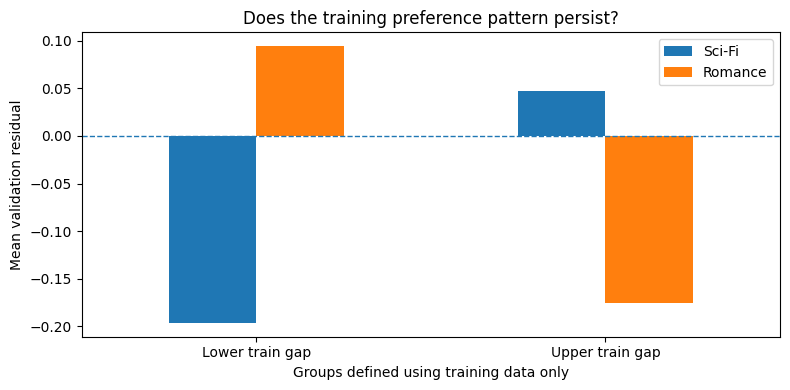

In [19]:
held_out = genre_residuals(validation, baseline, movies).pivot_table(
    index="user_id", columns="genre", values="residual", aggfunc="mean"
).dropna()
held_out = held_out.join(user_group).dropna(subset=["group"])

if held_out.empty:
    print("Too few eligible validation users for this descriptive comparison.")
else:
    display(held_out.groupby("group").size().rename("Users").to_frame())
    residual_summary = held_out.groupby("group")[["Sci-Fi", "Romance"]].mean()
    display(residual_summary)
    ax = residual_summary.plot.bar(figsize=(8, 4), rot=0)
    ax.set(
        xlabel="Groups defined using training data only",
        ylabel="Mean validation residual",
        title="Does the training preference pattern persist?",
    )
    ax.axhline(0, linewidth=1, linestyle="--")
    ax.figure.tight_layout()
    plt.show()

A global tendency to rate generously is not a complete description
of a person's preferences. Does the held-out table contain a pattern that the
baseline did not capture?

## One final table · RMSE and HitRate

RMSE measures rating error on the held-out observed pairs $\mathcal O$:

$$
\operatorname{RMSE}
=\sqrt{\frac{1}{|\mathcal O|}
\sum_{(u,i)\in\mathcal O}(r_{ui}-\widehat r_{ui})^2}.
$$

For HitRate, each evaluated user has a nonempty set $T_u$ of held-out movies
rated at least 4. Let $R_u^{(K)}$ be the recommended top-$K$ list. A hit means
that **at least one** such movie is in the list:

$$
\operatorname{HR}@K
=\frac{1}{|U_{\rm eval}|}
\sum_{u\in U_{\rm eval}}
\mathbf 1\{R_u^{(K)}\cap T_u\ne\varnothing\}.
$$

For example, if 3 of 10 users get at least one hit, HitRate is 0.3.
We use the entire declared movie catalog and exclude training-rated movies.
Test users without a held-out movie rated at least 4 are not in the HitRate
population. RMSE still uses all observed test ratings.

The test table is a final check, not an invitation to change model settings.

In [20]:
def rmse(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    if actual.shape != predicted.shape or actual.size == 0:
        raise ValueError("Use matching nonempty arrays for RMSE.")
    return float(np.sqrt(np.mean((actual - predicted) ** 2)))


def hit_rate(recommendations, targets):
    """Mean of one hit/no-hit indicator per user; targets may contain many IDs."""
    if len(recommendations) != len(targets) or not len(targets):
        raise ValueError("Use matching nonempty recommendation/target lists.")
    if any(len(target) == 0 for target in targets):
        raise ValueError("Every evaluated user must have a held-out target.")
    return float(
        np.mean(
            [
                np.isin(recommended, target).any()
                for recommended, target in zip(recommendations, targets)
            ]
        )
    )

In [21]:
targets = (
    test.query("rating >= 4")
    .groupby("user_id")["item_id"]
    .apply(np.array)
)
evaluation_ids = targets.index.to_numpy()
item_prior = item_stats["smoothed_rating"].to_numpy()

final_rows = []
for name in ["Item mean with prior", "Baseline predictors"]:
    if name == "Item mean with prior":
        predictions = item_prior[test["item_id"].to_numpy()]
        score_for_user = lambda user: item_prior
    else:
        predictions = baseline.predict(test)
        score_for_user = baseline.scores

    recommendations = [
        top_items(
            score_for_user(user),
            k=TOP_K,
            excluded=known_items.get(user, []),
        )
        for user in evaluation_ids
    ]
    final_rows.append(
        {
            "Model": name,
            "Test RMSE": rmse(test["rating"].to_numpy(), predictions),
            f"Test HitRate@{TOP_K}": hit_rate(
                recommendations, targets.to_list()
            ),
        }
    )

print(f"HitRate population: {len(evaluation_ids)} users")
display(pd.DataFrame(final_rows).set_index("Model"))

HitRate population: 5734 users


,Test RMSE,Test HitRate@10
Model,,
Item mean with prior,0.981,0.278
Baseline predictors,0.909,0.206


**A question to keep for later:** Do the two columns put the models in the
same order? Record what happened; the explanation belongs to a later session.

## Experiment 5 · Popular over the whole history, or popular now?

**Predict:** Can a shorter, more recent history give a useful recommendation
list? Or will it simply throw away evidence?

We make a recommendation at a fixed global time $T$. Only records with
$t<T$ are visible. We count **positive rating records** ($r_{ui}\ge4$), not
movie views and not mean ratings. This definition is the same for every rule below.

For movie $i$, let $P_i(T)$ contain its positive records before $T$:

$$
s_i^{\rm all}(T)=\sum_{e\in P_i(T)}1,\qquad
s_i^{\rm recent}(T)=\sum_{e\in P_i(T)}
   \mathbf 1\{T-W\le t_e<T\},
$$
$$
s_i^{\rm decay}(T)=\sum_{e\in P_i(T)}2^{-(T-t_e)/h}.
$$

Times are measured in days; $W=30$ days and the half-life $h=30$ days are
fixed before the run. A record 30 days old contributes one half to the
decay score; one 60 days old contributes one quarter. We do not search
for the best window or half-life during this exercise.

**Important:** MovieLens provides timestamps on rating records, not separate
viewing timestamps. A change in this log is not by itself evidence of a
change in individual taste, box-office demand, or movie-viewing time.

### A fixed forecast, not another random split

The three cutoffs below are chosen in advance. Each forecast uses the next
30 days. At each cutoff:

- Candidates are movies with at least one earlier rating of any value.
- Exclude each user's **entire** earlier rated history, not only the recent
  window and not only positive ratings.
- Evaluate existing users with an unseen, positive future rating in this
  catalog and at least $K$ available candidates. Keep the first such record
  per user as the target; exact timestamp ties use increasing item ID.
- Every scoring rule uses exactly these users, targets, masks and candidates.
  A movie with no recent positive records stays eligible with score zero.

This evaluates a deliberately restricted warm-user, warm-item population.
The audit reports exclusions; it does not silently count an empty population
as zero HitRate. The original random split is **not** used in this section.

### Prepare each forecast directly from the original log

The following cells contain all temporal preparation. `past` contains every
rating before the cutoff; `signal` keeps its positive ratings only. Candidate
movies and already-rated masks come from **all** of `past`. Future records are
used only to choose hidden targets, never to compute a score.

In [22]:
SECONDS_PER_DAY = 86_400


@dataclass
class TemporalTask:
    """One forecast made at a global cutoff, with frozen users and candidates."""

    cutoff: pd.Timestamp
    past: pd.DataFrame
    signal: pd.DataFrame
    candidates: np.ndarray
    known: dict
    target_frame: pd.DataFrame
    audit: dict

    @property
    def users(self):
        return self.target_frame["user_id"].to_numpy(dtype=int)

    @property
    def targets(self):
        return [[item] for item in self.target_frame["item_id"].to_numpy()]

In [23]:
def utc_time(value):
    """Interpret a date or timestamp in UTC; reject missing values."""
    timestamp = pd.Timestamp(value)
    if pd.isna(timestamp):
        raise ValueError("The cutoff must be a valid date.")
    if timestamp.tzinfo is None:
        return timestamp.tz_localize("UTC")
    return timestamp.tz_convert("UTC")

In [24]:
def make_temporal_task(ratings, cutoff, horizon_days=30, k=10):
    """Use t < cutoff for scoring, and the next interval for hidden targets.

    The signal is the count of ratings >= 4. The candidate catalog and seen-item
    masks use ALL earlier ratings, including low ratings. Select the first future
    positive event that is in this catalog, unseen, and from an existing user.
    This is a rating-log forecasting exercise, not a viewing-time reconstruction.
    """
    if horizon_days <= 0 or k <= 0:
        raise ValueError("The horizon and list length must be positive.")
    columns = {"timestamp", "user_id", "item_id", "rating"}
    if not columns.issubset(ratings.columns):
        raise ValueError(f"Required columns: {sorted(columns)}")
    if ratings[list(columns)].isna().any().any():
        raise ValueError("Missing values in required rating columns.")
    cutoff = utc_time(cutoff)
    boundary = cutoff.timestamp()
    end = boundary + horizon_days * SECONDS_PER_DAY
    past = ratings.loc[ratings["timestamp"] < boundary].copy()
    if past.empty:
        raise ValueError("No history before this cutoff; choose a date in the log.")
    signal = past.loc[past["rating"] >= 4].copy()
    candidates = np.sort(past["item_id"].unique())
    known = past.groupby("user_id")["item_id"].apply(np.unique).to_dict()
    future = ratings.loc[
        ratings["timestamp"].ge(boundary) & ratings["timestamp"].lt(end)
    ]
    positive = future.loc[future["rating"] >= 4].copy()
    warm_users = positive.loc[positive["user_id"].isin(known)].copy()
    warm_items = warm_users.loc[warm_users["item_id"].isin(candidates)].copy()
    seen_pairs = pd.MultiIndex.from_frame(past[["user_id", "item_id"]])
    future_pairs = pd.MultiIndex.from_frame(warm_items[["user_id", "item_id"]])
    unseen = warm_items.loc[~future_pairs.isin(seen_pairs)].copy()
    enough_candidates = {
        user for user, items in known.items() if len(candidates) - len(items) >= k
    }
    eligible = unseen.loc[unseen["user_id"].isin(enough_candidates)]
    targets = (
        eligible.sort_values(["timestamp", "item_id", "user_id"])
        .drop_duplicates("user_id")
        .sort_values("user_id")
        .reset_index(drop=True)
    )
    audit = {
        "Cutoff (UTC)": cutoff.date().isoformat(),
        "Past ratings": len(past),
        "Past positive ratings": len(signal),
        "Candidate movies": len(candidates),
        "Future positive ratings": len(positive),
        "Removed: new users": len(positive) - len(warm_users),
        "Removed: new items": len(warm_users) - len(warm_items),
        "Removed: already rated": len(warm_items) - len(unseen),
        "Removed: insufficient candidates": len(unseen) - len(eligible),
        "Evaluated users": len(targets),
    }
    return TemporalTask(cutoff, past, signal, candidates, known, targets, audit)

In [25]:
def compare_temporal_scores(task, scores_by_name, k=10):
    """All scorers share exactly one evaluation task, including full seen masks."""
    rows = []
    lists = {}
    for name, scores in scores_by_name.items():
        recommendations = [
            top_items(scores, k=k, candidates=task.candidates, excluded=task.known[u])
            for u in task.users
        ]
        lists[name] = recommendations
        value = hit_rate(recommendations, task.targets) if len(task.users) else np.nan
        rows.append(
            {
                "Method": name,
                "Evaluated users": len(task.users),
                f"HitRate@{k}": value,
            }
        )
    return pd.DataFrame(rows).set_index("Method"), lists

In [26]:
CUTOFFS = ["2000-08-01", "2000-10-01", "2000-12-01"]
WINDOW_DAYS = 30
HALF_LIFE_DAYS = 30
HORIZON_DAYS = 30
CONTROL_SEEDS = [2026, 2027, 2028]

time_tasks = [
    make_temporal_task(ratings, date, horizon_days=HORIZON_DAYS, k=TOP_K)
    for date in CUTOFFS
]
display(pd.DataFrame([task.audit for task in time_tasks]).set_index("Cutoff (UTC)"))

,Past ratings,Past positive ratings,Candidate movies,Future positive ratings,Removed: new users,Removed: new items,Removed: already rated,Removed: insufficient candidates,Evaluated users
Cutoff (UTC),,,,,,,,,
2000-08-01,223653,132343,3319,102060,97192,58,0,0,177
2000-10-01,458183,266469,3520,23997,19283,46,0,0,233
2000-12-01,791270,458067,3662,64036,49246,1,0,0,522


In [27]:
def recency_scores(task, catalog_size, window_days=30, half_life_days=30):
    """Build three rules from positive records strictly before one cutoff."""
    if window_days <= 0 or half_life_days <= 0:
        raise ValueError("Use a positive window and half-life.")
    items = task.signal["item_id"].to_numpy(dtype=int)
    age_days = (
        task.cutoff.timestamp() - task.signal["timestamp"].to_numpy()
    ) / SECONDS_PER_DAY
    if np.any(age_days <= 0):
        raise ValueError("A scoring record is at or after the cutoff.")
    recent = age_days <= window_days
    return {
        "All history": np.bincount(items, minlength=catalog_size).astype(float),
        "Recent window": np.bincount(
            items[recent], minlength=catalog_size
        ).astype(float),
        "Exponential decay": np.bincount(
            items,
            weights=np.exp2(-age_days / half_life_days),
            minlength=catalog_size,
        ),
    }

In [28]:
# One predefined cutoff for the list and history plots: no future-based search.
anchor_task = time_tasks[1]
anchor_scores = recency_scores(
    anchor_task, n_items, WINDOW_DAYS, HALF_LIFE_DAYS
)
leaders = {
    name: top_items(scores, k=8, candidates=anchor_task.candidates)
    for name, scores in anchor_scores.items()
}
display(
    pd.DataFrame(
        {
            name: movies.loc[items, "title"].to_numpy()
            for name, items in leaders.items()
        },
        index=np.arange(1, 9),
    ).rename_axis("Position")
)

,All history,Recent window,Exponential decay
Position,,,
1,American Beauty (1999),American Beauty (1999),American Beauty (1999)
2,Star Wars: Episode IV - A New Hope (1977),Fargo (1996),Star Wars: Episode IV - A New Hope (1977)
3,Star Wars: Episode V - The Empire Strikes Back (1980),Star Wars: Episode IV - A New Hope (1977),Star Wars: Episode V - The Empire Strikes Back (1980)
4,"Sixth Sense, The (1999)","Silence of the Lambs, The (1991)","Silence of the Lambs, The (1991)"
5,"Silence of the Lambs, The (1991)","Sixth Sense, The (1999)","Matrix, The (1999)"
6,Raiders of the Lost Ark (1981),"Matrix, The (1999)","Sixth Sense, The (1999)"
7,"Matrix, The (1999)",Star Wars: Episode V - The Empire Strikes Back (1980),Fargo (1996)
8,Saving Private Ryan (1998),"Usual Suspects, The (1995)",Raiders of the Lost Ark (1981)


### Are we seeing a shift in attention, or just more records?

Plot the weekly **share of positive records** for up to four movies: the
first two all-history leaders and the first two recent-window leaders at
the predefined cutoff. Selection and curves use earlier data only.

A share divides a movie's weekly count by the total positive count that week.
It prevents a rise in total logging activity from looking automatically like
a rise for every movie. It does not control for changes in who supplies ratings.

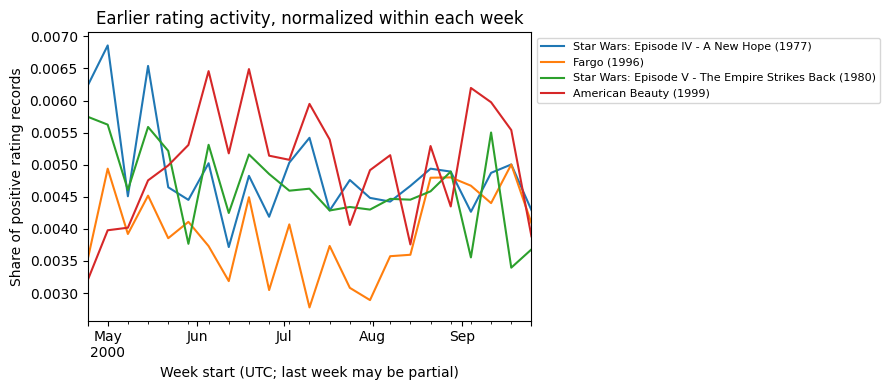

In [29]:
selected_movies = np.unique(
    np.concatenate([leaders["All history"][:3], leaders["Recent window"][:3]])
)
weekly_log = anchor_task.signal.copy()
weekly_log["week"] = (
    pd.to_datetime(weekly_log["timestamp"], unit="s", utc=True)
    .dt.tz_localize(None)
    .dt.to_period("W-SUN")
    .dt.start_time
)
weekly_total = weekly_log.groupby("week").size()
weekly_movies = (
    weekly_log.loc[weekly_log["item_id"].isin(selected_movies)]
    .groupby(["week", "item_id"]).size().unstack("item_id")
    .reindex(index=weekly_total.index, columns=selected_movies).fillna(0)
)
weekly_share = weekly_movies.div(weekly_total, axis=0)
calendar = pd.date_range(
    weekly_total.index.min(), weekly_total.index.max(), freq="7D"
)
weekly_share = weekly_share.reindex(calendar)
weekly_share.columns = movies.loc[selected_movies, "title"].to_list()
ax = weekly_share.plot(figsize=(9, 4))
ax.set(
    xlabel="Week start (UTC; last week may be partial)",
    ylabel="Share of positive rating records",
    title="Earlier rating activity, normalized within each week",
)
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1, 1))
ax.figure.tight_layout()
plt.show()